<a href="https://www.kaggle.com/code/sarraverse/02-fp-growth-experiments?scriptVersionId=289146375" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# FP-Growth on Instacart Transaction Data
# Frequent Itemsets and Association Rules

In [4]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [5]:
# ============================================================
# FP-Growth on Instacart Transaction Data
# Frequent Itemsets and Association Rules
# ============================================================


import os
import time
import uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load Preprocessed Transaction Matrix


In [6]:
# ============================================================
# 1. Load Preprocessed Transaction Matrix
# ============================================================

DATA_DIR = "/kaggle/input/01-preprocessing-and-eda/processed_instacart"
MATRIX_PATH = os.path.join(DATA_DIR, "instacart_transaction_matrix.parquet")

transaction_matrix = pd.read_parquet(MATRIX_PATH)
transaction_matrix = transaction_matrix.astype(bool)

print("Transaction matrix shape:", transaction_matrix.shape)
display(transaction_matrix.head())


Transaction matrix shape: (50000, 8290)


,#2 Coffee Filters,0% Fat Blueberry Greek Yogurt,0% Fat Free Organic Milk,0% Fat Organic Greek Vanilla Yogurt,0% Fat Superfruits Greek Yogurt,0% Greek Strained Yogurt,0% Greek Yogurt Black Cherry on the Bottom,"0% Greek, Blueberry on the Bottom Yogurt",1 % Lowfat Milk,1 Apple + 1 Mango Fruit Bar,...,Zucchini Noodles,Zucchini Soufflé,Zucchini Squash,for Tots Apple Juice,gel hand wash sea minerals,of Hanover 100 Calorie Pretzels Mini,smartwater® Electrolyte Enhanced Water,vitaminwater® XXX Acai Blueberry Pomegranate,with Crispy Almonds Cereal,with Olive Oil Mayonnaise
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 2. Reduce Matrix Size for FP-Growth

The saved matrix (150,000 × ~14,000) is still heavy for FP-Growth on Kaggle.  
To keep the experiment tractable while preserving structure, we:

- Keep only items that appear in at least a certain number of orders (column frequency).  
- Sample a subset of transactions (rows) for mining.  

This is a standard approach for applying FP-Growth on very large, sparse datasets like Instacart.[web:50][web:213]


In [7]:
# ============================================================
# 2. Reduce Matrix Size for FP-Growth
# ============================================================

print("Full transaction matrix shape:", transaction_matrix.shape)

# 2.1 Drop very rare items (columns)
MIN_COLUMN_SUM = 100  # keep items appearing in at least 100 orders
col_sums = transaction_matrix.sum(axis=0)
keep_cols = col_sums[col_sums >= MIN_COLUMN_SUM].index
transaction_matrix_small = transaction_matrix[keep_cols]

print("After column frequency filter:", transaction_matrix_small.shape)

# 2.2 Sample a subset of transactions (rows)
MAX_TRANSACTIONS_FP = 30_000  # reduce if still OOM

if transaction_matrix_small.shape[0] > MAX_TRANSACTIONS_FP:
    transaction_matrix_fp = transaction_matrix_small.sample(
        n=MAX_TRANSACTIONS_FP,
        random_state=42
    )
else:
    transaction_matrix_fp = transaction_matrix_small

print("FP-Growth will run on:", transaction_matrix_fp.shape)


Full transaction matrix shape: (50000, 8290)
After column frequency filter: (50000, 903)
FP-Growth will run on: (30000, 903)


## 3. FP-Growth Configuration and Utilities

In [8]:
# ============================================================
# 3. Experiment Configuration
# ============================================================

OUTPUT_DIR = "fp_growth_results_instacart"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Reduced grid to avoid excessive runtime/memory:
MIN_SUPPORT_VALUES = [0.005, 0.01]
MIN_CONFIDENCE_VALUES = [0.1, 0.2]
MIN_LIFT = 1.0

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 4. Utility Functions

In [9]:
# ============================================================
# 4. Utility Functions
# ============================================================

def run_fpgrowth(df_bool: pd.DataFrame, min_support: float) -> tuple[pd.DataFrame, float]:
    """Run FP-Growth and return frequent itemsets + runtime."""
    start_time = time.perf_counter()
    frequent_itemsets = fpgrowth(
        df_bool,
        min_support=min_support,
        use_colnames=True
    )
    elapsed = time.perf_counter() - start_time
    return frequent_itemsets, elapsed


def generate_rules_filtered(
    frequent_itemsets: pd.DataFrame,
    min_confidence: float,
    min_lift: float
) -> pd.DataFrame:
    """Generate association rules and filter by confidence and lift."""
    if frequent_itemsets.empty:
        return pd.DataFrame()

    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )
    rules = rules[rules["lift"] >= min_lift].reset_index(drop=True)
    return rules


def analyze_rule_lengths(rules: pd.DataFrame) -> pd.DataFrame:
    """Add antecedent/consequent lengths and total rule length."""
    if rules.empty:
        return rules

    rules = rules.copy()
    rules["antecedent_len"] = rules["antecedents"].apply(len)
    rules["consequent_len"] = rules["consequents"].apply(len)
    rules["rule_len"] = rules["antecedent_len"] + rules["consequent_len"]
    return rules

def compute_rule_metrics(rules: pd.DataFrame) -> dict:
    """Compute aggregated rule metrics for one FP-Growth experiment."""
    if rules.empty or "confidence" not in rules.columns or "lift" not in rules.columns:
        return {
            "avg_confidence": 0.0,
            "avg_lift": 0.0,
            "max_lift": 0.0,
        }
    return {
        "avg_confidence": float(rules["confidence"].mean()),
        "avg_lift": float(rules["lift"].mean()),
        "max_lift": float(rules["lift"].max()),
    }


def save_rules_and_metrics(
    rules: pd.DataFrame,
    experiment_id: str,
    min_support: float,
    min_confidence: float,
    min_lift: float,
    runtime_sec: float,
    n_itemsets: int,
    output_dir: str
) -> dict:
    """Save rules to CSV and return a summary dict."""
    base_name = f"fp_growth_{experiment_id}_sup{min_support}_conf{min_confidence}_lift{min_lift}"
    base_name = base_name.replace(".", "_")

    csv_path = os.path.join(output_dir, base_name + ".csv")
    rules.to_csv(csv_path, index=False)

    summary = {
        "experiment_id": experiment_id,
        "algorithm": "fp_growth",
        "min_support": min_support,
        "min_confidence": min_confidence,
        "min_lift": min_lift,
        "runtime_sec": runtime_sec,
        "n_frequent_itemsets": n_itemsets,
        "n_rules": rules.shape[0],
        "rules_path": csv_path,
    }
    return summary


## 5. Run FP-Growth Experiments

In [10]:
# ============================================================
# 5. Run FP-Growth Experiments
# ============================================================

results = []
all_rules = []  # store rules from all runs with tags

for min_sup in MIN_SUPPORT_VALUES:
    for min_conf in MIN_CONFIDENCE_VALUES:
        print("=" * 80)
        print(
            f"Running FP-Growth with min_support={min_sup}, "
            f"min_confidence={min_conf}, min_lift={MIN_LIFT}"
        )

        experiment_id = str(uuid.uuid4())[:8]

        # 5.1 Frequent itemset mining
        frequent_itemsets, runtime_sec = run_fpgrowth(
            transaction_matrix_fp,
            min_support=min_sup
        )

        n_itemsets = frequent_itemsets.shape[0]
        print(f"Frequent itemsets found: {n_itemsets}")
        print(f"Runtime (FP-Growth): {runtime_sec:.2f} seconds")

        if n_itemsets == 0:
            print("No itemsets found; skipping rule generation.")
            results.append(
                {
                    "experiment_id": experiment_id,
                    "algorithm": "fp_growth",
                    "min_support": min_sup,
                    "min_confidence": min_conf,
                    "min_lift": MIN_LIFT,
                    "runtime_sec": runtime_sec,
                    "n_frequent_itemsets": 0,
                    "n_rules": 0,
                    "rules_path": None,
                    "avg_confidence": 0.0,
                    "avg_lift": 0.0,
                    "max_lift": 0.0,
                }
            )
            continue

        # 5.2 Association rules
        rules = generate_rules_filtered(
            frequent_itemsets,
            min_confidence=min_conf,
            min_lift=MIN_LIFT
        )
        rules = analyze_rule_lengths(rules)

        print(f"Rules generated after filtering: {rules.shape[0]}")

        # NEW: aggregated rule metrics
        rule_metrics = compute_rule_metrics(rules)

        # 5.3 Save rules and metrics
        if not rules.empty:
            summary = save_rules_and_metrics(
                rules,
                experiment_id=experiment_id,
                min_support=min_sup,
                min_confidence=min_conf,
                min_lift=MIN_LIFT,
                runtime_sec=runtime_sec,
                n_itemsets=n_itemsets,
                output_dir=OUTPUT_DIR
            )

            # enrich summary with avg/max metrics
            summary["avg_confidence"] = rule_metrics["avg_confidence"]
            summary["avg_lift"] = rule_metrics["avg_lift"]
            summary["max_lift"] = rule_metrics["max_lift"]

            results.append(summary)

            # keep rules with experiment metadata
            rules_meta = rules.copy()
            rules_meta["experiment_id"] = experiment_id
            rules_meta["min_support"] = min_sup
            rules_meta["min_confidence"] = min_conf
            rules_meta["min_lift"] = MIN_LIFT
            all_rules.append(rules_meta)
        else:
            print("No rules passed thresholds; nothing saved.")
            results.append(
                {
                    "experiment_id": experiment_id,
                    "algorithm": "fp_growth",
                    "min_support": min_sup,
                    "min_confidence": min_conf,
                    "min_lift": MIN_LIFT,
                    "runtime_sec": runtime_sec,
                    "n_frequent_itemsets": n_itemsets,
                    "n_rules": 0,
                    "rules_path": None,
                    "avg_confidence": 0.0,
                    "avg_lift": 0.0,
                    "max_lift": 0.0,
                }
            )


Running FP-Growth with min_support=0.005, min_confidence=0.1, min_lift=1.0
Frequent itemsets found: 368
Runtime (FP-Growth): 7.97 seconds
Rules generated after filtering: 112
Running FP-Growth with min_support=0.005, min_confidence=0.2, min_lift=1.0
Frequent itemsets found: 368
Runtime (FP-Growth): 7.89 seconds
Rules generated after filtering: 51
Running FP-Growth with min_support=0.01, min_confidence=0.1, min_lift=1.0
Frequent itemsets found: 128
Runtime (FP-Growth): 2.08 seconds
Rules generated after filtering: 27
Running FP-Growth with min_support=0.01, min_confidence=0.2, min_lift=1.0
Frequent itemsets found: 128
Runtime (FP-Growth): 1.95 seconds
Rules generated after filtering: 13


## 6. Aggregate and Save Results

In [11]:
# ============================================================
# 6. Aggregate Results
# ============================================================

results_df = pd.DataFrame(results)
print("Experiment summary:")
display(results_df)

results_path = os.path.join(OUTPUT_DIR, "fp_growth_experiments_summary.csv")
results_df.to_csv(results_path, index=False)
print("Saved experiment summary to:", results_path)

if all_rules:
    all_rules_df = pd.concat(all_rules, ignore_index=True)
else:
    all_rules_df = pd.DataFrame()

all_rules_path = os.path.join(OUTPUT_DIR, "fp_growth_all_rules.csv")
all_rules_df.to_csv(all_rules_path, index=False)
print("Saved all rules to:", all_rules_path)


Experiment summary:


,experiment_id,algorithm,min_support,min_confidence,min_lift,runtime_sec,n_frequent_itemsets,n_rules,rules_path,avg_confidence,avg_lift,max_lift
0,8dc847b3,fp_growth,0.005,0.1,1.0,7.969078,368,112,fp_growth_results_instacart/fp_growth_8dc847b3...,0.197293,2.139184,5.177828
1,aafc7837,fp_growth,0.005,0.2,1.0,7.885893,368,51,fp_growth_results_instacart/fp_growth_aafc7837...,0.253876,2.138883,5.177828
2,83ddea32,fp_growth,0.010,0.1,1.0,2.078399,128,27,fp_growth_results_instacart/fp_growth_83ddea32...,0.197424,1.939727,2.762213
3,c2c87fa2,fp_growth,0.010,0.2,1.0,1.949138,128,13,fp_growth_results_instacart/fp_growth_c2c87fa2...,0.258547,1.903141,2.762213


Saved experiment summary to: fp_growth_results_instacart/fp_growth_experiments_summary.csv
Saved all rules to: fp_growth_results_instacart/fp_growth_all_rules.csv


## 7. Visualizations

We now analyze how the number and quality of rules change with support and confidence, and inspect rule lengths.


## 7.1 Number of rules vs support

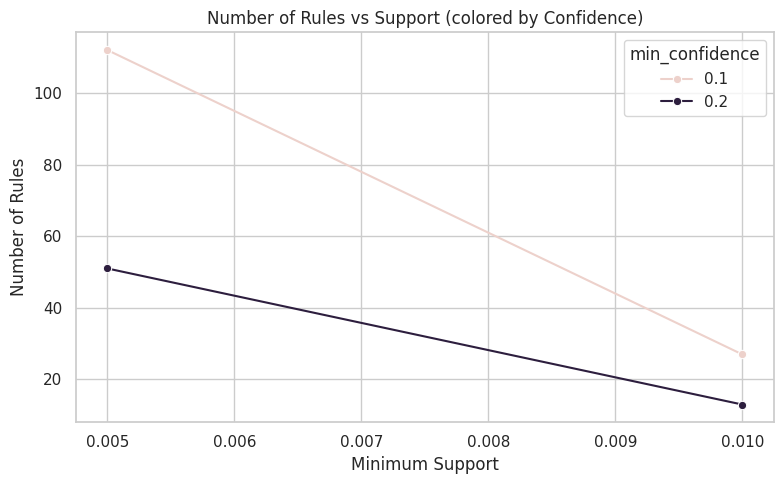

In [12]:
# ============================================================
# 7.1 Number of rules vs support
# ============================================================

if not results_df.empty:
    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=results_df,
        x="min_support",
        y="n_rules",
        hue="min_confidence",
        marker="o"
    )
    plt.title("Number of Rules vs Support (colored by Confidence)")
    plt.xlabel("Minimum Support")
    plt.ylabel("Number of Rules")
    plt.tight_layout()
    plt.show()


## 7.2 Confidence vs Lift scatter plot

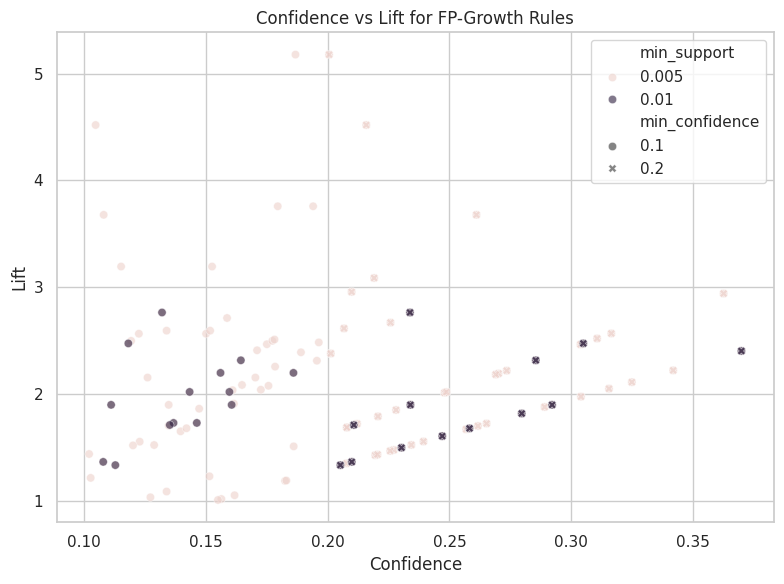

In [13]:
# ============================================================
# 7.2 Confidence vs Lift scatter plot
# ============================================================

if not all_rules_df.empty:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=all_rules_df,
        x="confidence",
        y="lift",
        hue="min_support",
        style="min_confidence",
        alpha=0.6
    )
    plt.title("Confidence vs Lift for FP-Growth Rules")
    plt.xlabel("Confidence")
    plt.ylabel("Lift")
    plt.tight_layout()
    plt.show()


## 7.3 Distribution of rule lengths

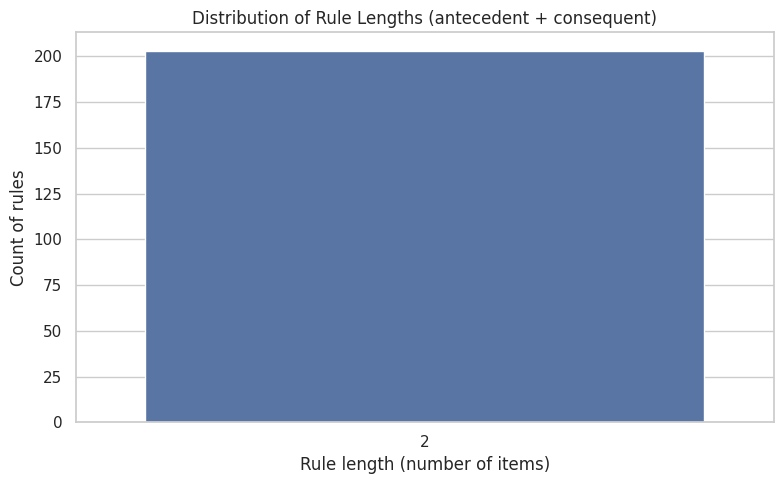

In [14]:
# ============================================================
# 7.3 Distribution of rule lengths
# ============================================================

if not all_rules_df.empty:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=all_rules_df,
        x="rule_len"
    )
    plt.title("Distribution of Rule Lengths (antecedent + consequent)")
    plt.xlabel("Rule length (number of items)")
    plt.ylabel("Count of rules")
    plt.tight_layout()
    plt.show()


## 8. Conclusions

- FP-Growth was successfully applied on a **reduced Instacart subset**, making the problem tractable within Kaggle’s memory limits while preserving meaningful co‑occurrence patterns.[file:232][web:84]  
- As expected, **higher minimum support** leads to fewer rules, while lower support and confidence reveal more, but potentially weaker, associations.[web:80][web:228]  
- The rule length distribution indicates whether most patterns are simple pairwise relations or involve more complex baskets, which is important for recommendation design and interpretability.[web:224][web:227]  

All experiments are logged with unique `experiment_id` values, and rule files are saved with hyperparameters encoded in their filenames, enabling direct comparison with Apriori in a later notebook.
